# Digital Experimentation and Causal Analysis- Group Project, Group 50- TXB 
Lucia Musizzano, Pietro Franchi, Leonardo Cantú, Maria Teresa Neves Silva, José João Nascimento Almeida
## A/B Test – Visual Redesign of Benefit Plans
Group 50 – Digital Experimentation and Causal Analysis
This notebook implements the analysis pipeline for our A/B test.
It includes:
- Data loading  
- Metric computation  
- Statistical tests  
- Power analysis  
- Interpretation  

In [35]:
# 1. Import Libraries:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# 2. Load (temporary) dataset 
df = pd.read_csv("simulated_ab_test_data_B1.csv")

# 3. Cleaning
df.head()

#4. Configure plotting style
plt.style.use('seaborn-v0_8')

In [36]:
# 5. Inspect dataset structure
# We check column names to ensure that all metrics we will calculate exist in the dataset.
df.columns.tolist()

['group',
 'ctr',
 'interactions',
 'dwell_time',
 'latency',
 'translate_click',
 'first_action_time',
 'bounce',
 'gender',
 'browser_language']

In [42]:
df['ctr'].unique()

array([0.        , 0.04830378, 0.07162063, ..., 0.10305409, 0.09044853,
       0.06695148], shape=(1087,))

### 1) Compute A/B Test Metrics
We compute the KPIs defined in the project:
- **CTR (Click‑through Rate)** — Primary metric  
- **Time To First Action (TTFA)** — Secondary metric  
- **Interactions** — Engagement metric  
- **Bounce Rate** — Guardrail metric  
We save all results into a dictionary so they can be easily reused later.

In [37]:
# 6. Creating Metrics (dictionary)
metrics = {}

# 7. Primary metric: Click-through rate (CTR)
metrics['CTR_A'] = df[df.group=='A'].ctr.mean()
metrics['CTR_B'] = df[df.group=='B'].ctr.mean()

# 8. Time to first action (TTFA)
metrics['TTFA_A'] = df[df.group=='A'].first_action_time.mean()
metrics['TTFA_B'] = df[df.group=='B'].first_action_time.mean()

# 9. Interactions average (INTERACT)
metrics['INTERACT_A'] = df[df.group=='A'].interactions.mean()
metrics['INTERACT_B'] = df[df.group=='B'].interactions.mean()

# 10. Bounce rate
metrics['BR_A'] = df[(df.group=='A') & (df.bounce==1)].shape[0] / df[df.group=='A'].shape[0]
metrics['BR_B'] = df[(df.group=='B') & (df.bounce==1)].shape[0] / df[df.group=='B'].shape[0]

# 11. Display results
metrics_df = pd.DataFrame(metrics, index=['Group A', 'Group B'])
metrics_df

,CTR_A,CTR_B,TTFA_A,TTFA_B,INTERACT_A,INTERACT_B,BR_A,BR_B
Group A,0.027754,0.115405,5.87612,5.281832,24.221569,7.038431,0.40648,0.382916
Group B,0.027754,0.115405,5.87612,5.281832,24.221569,7.038431,0.40648,0.382916


1. **Clik Through Rate (CTR)**: is the percentage of users who clicked on a specific link or button. 
It is calculated as (number of clicks / number of impressions) * 100. It as been set as the primary metric for this A/B test because it directly measures user engagement with the feature being tested. 
If CTR_B>CTR_A then the new versison should be implemented. 
2. **Time to First Action (TTFA)**: is used to check whether the proposed versison can 
    - optimize scrolling and navigation time 
    - riduce "cognitive load"
It is a secondary KPI, linked to the page fluidity. 
3. **Interactions Average**: this metrics shows the number of total interactions for users (e.g. scroll, clicks,...). 
4. **Bounce Rate**: a "bouncing" users is one that enters the page but **doesn't** interact and exits. It is a guardrail metric and it is useful when checking if the new proposal improves the user's experience and the traffic doen't get penalized.

### 2) Statistical Test 
We test whether the differences between A and B are statistically significant.
Tests used:
- **Proportion test** for CTR  
- **T-tests** for TTFA and Interactions

In [47]:
# 12. T-test for CTR
t_ctr, p_ctr = ttest_ind(
    df[df.group=='A'].ctr,
    df[df.group=='B'].ctr,
    equal_var=False
)

print("----- T-test: CTR -----")
print("p-value:", p_ctr)

----- T-test: CTR -----
p-value: 7.104836136320927e-287


In [48]:
# 13. Confidence Interval for CTR difference

ctr_A = df[df.group=='A'].ctr
ctr_B = df[df.group=='B'].ctr

mean_diff = ctr_B.mean() - ctr_A.mean()

# 14. standard error
se = np.sqrt(ctr_A.var()/len(ctr_A) + ctr_B.var()/len(ctr_B))

# 95% CI
z = 1.96
ci_lower = mean_diff - z*se
ci_upper = mean_diff + z*se

print("CTR difference (B - A):", mean_diff)
print("95% CI:", (ci_lower, ci_upper))

CTR difference (B - A): 0.08765108873190233
95% CI: (np.float64(0.0839954875691072), np.float64(0.09130668989469747))


**Confidence Interval Interpretation**: The 95% confidence interval for the CTR difference (B − A) does not include zero, confirming that the improvement in Variant B is statistically significant.

In [49]:
# T-tests for continuous metrics
# 15. TTFA
t_tffa, p_tffa = ttest_ind(
    df[df.group=='A'].first_action_time,
    df[df.group=='B'].first_action_time,
    equal_var=False
)

# 16. Interactions
t_inter, p_inter = ttest_ind(
    df[df.group=='A'].interactions,
    df[df.group=='B'].interactions,
    equal_var=False
)

print("----- T-test: TTFA -----")
print("p-value:", p_tffa)

print("\n----- T-test: Interactions -----")
print("p-value:", p_inter)


----- T-test: TTFA -----
p-value: 1.2521050694622679e-20

----- T-test: Interactions -----
p-value: 1.4266571314795108e-176


### 3) Power Analysis
We estimate whether the sample size is sufficient to detect the observed CTR difference.


In [ ]:
# 17. Power analysis based on CTR difference

effect = proportion_effectsize(p_B, p_A)

power = NormalIndPower().solve_power(
    effect_size=effect,
    nobs1=n_A,
    alpha=0.05,
    ratio=n_B/n_A,
    power=None
)

print("----- Power Analysis -----")
print("Observed power:", power)


----- Power Analysis -----
Observed power: 0.9999983002293258


### 4)Visualization:
We generate bar charts to show the metric differences clearly.

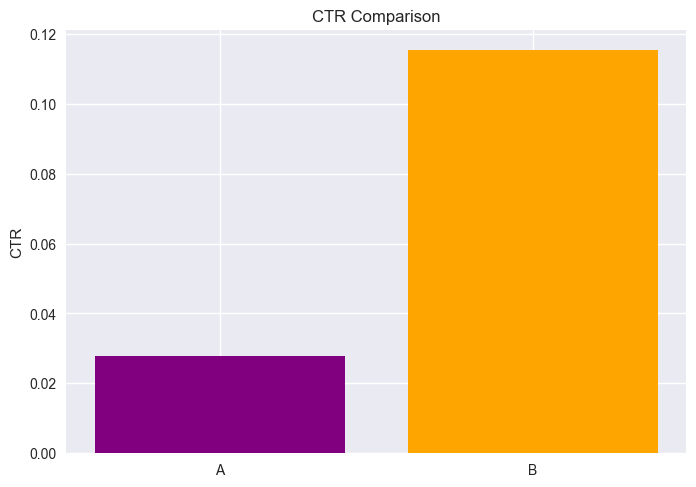

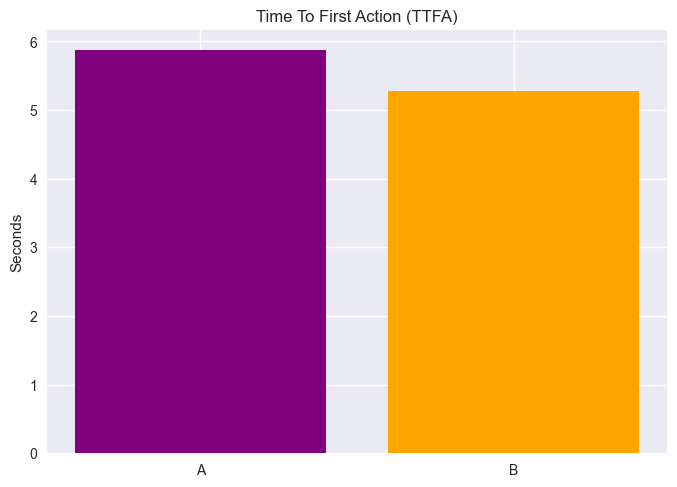

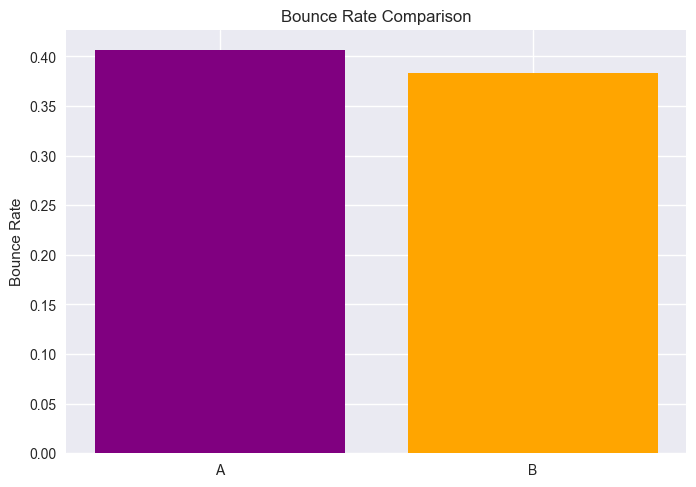

In [ ]:
# 18. CTR Comparison Chart

plt.bar(['A','B'], [metrics['CTR_A'], metrics['CTR_B']], color=['purple','orange'])
plt.title('CTR Comparison')
plt.ylabel('CTR')
plt.show()

# 19. TTFA Chart
plt.bar(['A','B'], [metrics['TTFA_A'], metrics['TTFA_B']], color=['purple','orange'])
plt.title('Time To First Action (TTFA)')
plt.ylabel('Seconds')
plt.show()

# 20.Bounce Rate Chart
plt.bar(['A','B'], [metrics['BR_A'], metrics['BR_B']], color=['purple','orange'])
plt.title('Bounce Rate Comparison')
plt.ylabel('Bounce Rate')
plt.show()


### 5) Conclusion: 

**Conclusion:** 